In [1]:
import pandas as pd

df_draft = pd.read_csv('cleaned_data_final_draft.csv')
df_draft.head()

,filepath,patient_name,birth_year,xray_type,datetime
0,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE AP,2024-02-26 08:47:23
1,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE AP,2024-02-26 08:47:52
2,../XQUANG\20240226\20240226013\20240226013_202...,MA THI NGUYET,1973.0,SPINE AP,2024-02-26 08:48:13
3,../XQUANG\20240226\20240226014\20240226014_202...,NGUYEN DANG TUAN,1954.0,CHEST PA,2024-02-26 09:10:10
4,../XQUANG\20240226\20240226015\20240226015_202...,NGUYEN QUE,1946.0,SKULLI AP,2024-02-26 09:15:43


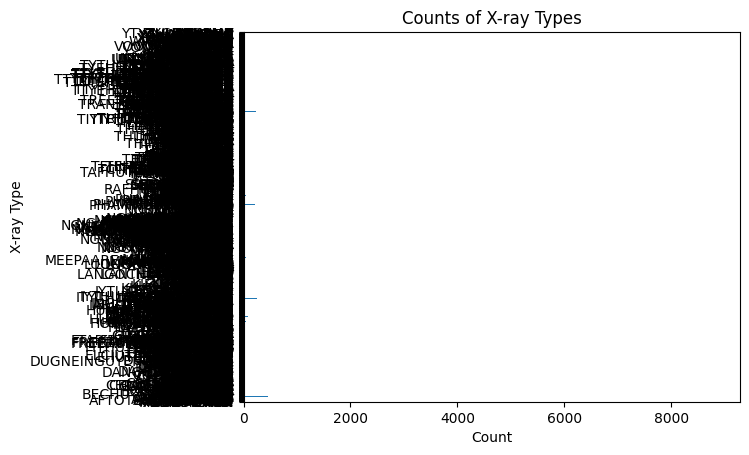

In [2]:
import matplotlib.pyplot as plt

# Clusterd data by 'xray_type' column and show chart counts
grouped = df_draft.groupby('xray_type')
grouped.size().plot(kind='barh', title='Counts of X-ray Types')
plt.xlabel('Count')
plt.ylabel('X-ray Type')
plt.show()

In [5]:
# List all xray types in the dataset with counts
xray_counts = df_draft['xray_type'].value_counts()
for xray_type, count in xray_counts.items():
    print(f"{xray_type}: {count}")

CHEST PA: 8838
SKULL AP: 4220
SPINE AP: 2940
NGUYEN: 2525
HUYENDUC: 1444
FOREARM: 1429
WRIST: 1228
SPINE LAT: 1121
SKULLAP: 942
SHOULDER: 818
SKULLI AP: 686
CHEST AP: 566
KNEE: 546
PELVIS AP: 481
ABDOMEN AP: 458
ANKLE: 450
THANH: 371
SKULL: 284
TTYTHUYEN: 249
ITYT: 247
TRAN: 230
ELBOW: 224
PHAM: 220
PHUONG: 212
CHESTPA: 195
TRUONG: 180
HUYNH: 178
R AP: 144
DUONG: 140
SKULLA AP: 136
FOREARM OBL: 134
LUONG: 130
QUANG: 127
SHOULDERRAP: 120
DUCTRONG: 115
FOOT: 107
KHANH: 102
HAND: 97
THIEN: 85
HUONG: 84
DANG: 83
NGUYENTHI: 81
TRINH: 81
UTYT: 78
NGOC: 75
HUMERUS: 74
PHUNG: 70
PHAN: 68
QUYNH: 65
HOANG: 61
SPINEAP: 59
PHONG: 55
MINH: 55
HUYENDUCTRONG: 53
XUAN: 52
HOYEN: 51
TRIEU: 51
DINH: 50
TTYTEHUYEN: 48
THINH: 47
TUYET: 43
HONG: 42
HANDLAP: 42
KHANG: 41
TRANG: 39
CUONG: 38
ANKLERAP: 35
KNEERAP: 34
QUYEN: 33
DUYEN: 33
THUONG: 33
TEST: 32
HUYENDUG: 32
PHUOC: 31
THANG: 30
DOAN: 29
TUONG: 28
DONG: 28
THUY: 28
TUAN: 27
TTYTEHUYENDUC: 27
BOTH AP: 27
TESST: 26
KLONG: 26
CHIEN: 26
NGUYET: 26
TUYEN

In [6]:
# Remove space characters from 'xray_type' column
df_draft['xray_type'] = df_draft['xray_type'].str.replace(' ', '')

xray_counts = df_draft['xray_type'].value_counts()
for xray_type, count in xray_counts.items():
    print(f"{xray_type}: {count}")

CHESTPA: 9033
SKULLAP: 5162
SPINEAP: 2999
NGUYEN: 2525
HUYENDUC: 1444
FOREARM: 1429
WRIST: 1228
SPINELAT: 1126
SHOULDER: 818
SKULLIAP: 688
CHESTAP: 580
KNEE: 546
PELVISAP: 490
ABDOMENAP: 471
ANKLE: 450
THANH: 371
SKULL: 284
TTYTHUYEN: 249
ITYT: 247
TRAN: 230
ELBOW: 224
PHAM: 220
PHUONG: 212
TRUONG: 180
HUYNH: 178
RAP: 144
DUONG: 140
SKULLAAP: 136
FOREARMOBL: 135
LUONG: 130
QUANG: 127
SHOULDERRAP: 122
DUCTRONG: 115
FOOT: 107
KHANH: 102
HAND: 97
THIEN: 85
HUONG: 84
DANG: 83
NGUYENTHI: 81
TRINH: 81
UTYT: 78
NGOC: 75
HUMERUS: 74
PHUNG: 70
PHAN: 68
QUYNH: 65
HOANG: 61
PHONG: 55
MINH: 55
HUYENDUCTRONG: 53
XUAN: 52
TRIEU: 51
HOYEN: 51
DINH: 50
TTYTEHUYEN: 48
THINH: 47
TUYET: 43
HANDLAP: 42
HONG: 42
KHANG: 41
TRANG: 39
CUONG: 38
KNEERAP: 37
ANKLERAP: 35
DUYEN: 33
THUONG: 33
QUYEN: 33
HUYENDUG: 32
TEST: 32
PHUOC: 31
THANG: 30
DOAN: 29
DONG: 28
BOTHAP: 28
TUONG: 28
THUY: 28
TUAN: 27
TTYTEHUYENDUC: 27
KULLAP: 27
CHIEN: 26
KLONG: 26
TESST: 26
NGUYET: 26
SKULLPA: 26
VUONG: 24
LLAT: 24
TUYEN: 24
THI

In [7]:
import pandas as pd
import re

# 1. Định nghĩa từ điển Mapping cho bộ phận cơ thể (X-Ray)
# Key là nhãn CHUẨN, Value là danh sách các từ khóa tìm kiếm (bao gồm cả lỗi OCR phổ biến)
XRAY_MAPPING = {
    'CHEST': ['CHEST', 'THORAX', 'LUNG', 'RIB', 'CLAVICLE', 'HEST', 'CNEST', 'PHOI'],
    'SKULL': ['SKULL', 'HEAD', 'SINUS', 'MANDIBLE', 'ZYGOMA', 'NASAL', 'FACE', 'SO', 'HAM'],
    'SPINE': ['SPINE', 'CERVICAL', 'LUMBAR', 'THORACIC', 'SACRUM', 'COCCYX', 'NECK', 'COT SONG', 'L-SPINE', 'C-SPINE', 'T-SPINE'],
    'ABDOMEN': ['ABDOMEN', 'ABD', 'KUB', 'BUNG'],
    'PELVIS': ['PELVIS', 'HIP', 'SI JOINT', 'CHAU'],
    'KNEE': ['KNEE', 'PATELLA', 'GOI'],
    'SHOULDER': ['SHOULDER', 'SCAPULA', 'VAI'],
    'HAND': ['HAND', 'FINGER', 'THUMB', 'DIGIT', 'BAN TAY', 'NGON TAY'],
    'WRIST': ['WRIST', 'CARPAL', 'CO TAY'],
    'ELBOW': ['ELBOW', 'KHUYU'],
    'FOREARM': ['FOREARM', 'RADIUS', 'ULNA', 'CANG TAY'],
    'FOOT': ['FOOT', 'TOE', 'HEEL', 'CALCANEUS', 'BAN CHAN'],
    'ANKLE': ['ANKLE', 'CO CHAN'],
    'HUMERUS': ['HUMERUS', 'ARM', 'CANH TAY'],
    'FEMUR': ['FEMUR', 'THIGH', 'DUI'],
    'LEG': ['LEG', 'TIBIA', 'FIBULA', 'CANG CHAN']
}

# 2. Định nghĩa từ khóa nhận diện tên người Việt (Các Họ phổ biến)
VN_SURNAMES = [
    'NGUYEN', 'TRAN', 'LE', 'PHAM', 'HOANG', 'HUYNH', 'PHAN', 'VU', 'VO', 'DANG', 
    'BUI', 'DO', 'HO', 'NGO', 'DUONG', 'LY', 'TRINH', 'DINH', 'LAM', 'MAI', 
    'LUONG', 'TRUONG', 'THAI', 'CAO', 'CHAU', 'TA', 'PHUNG', 'KHUONG', 'QUACH', 
    'LA', 'TON', 'DIEP', 'KIEU', 'DAM', 'SON', 'CHU', 'THI', 'VAN'
]

# 3. Định nghĩa từ khóa nhận diện nhiễu địa chỉ (Đức Trọng)
# Bao gồm các biến thể lỗi OCR thường gặp
LOCATION_NOISE = [
    'TTYT', 'HUYEN', 'DUC', 'TRONG', 'YTE', 'HUTEN', 'DUG', 'RONG', 'LAM', 'DONG', 
    'CENTER', 'HOSPITAL', 'TYTHUYEN', 'TEHUYEN', 'LHUYEN', 'UHUYEN'
]

def normalize_and_classify(label):
    """
    Hàm chuẩn hóa và phân loại nhãn.
    Trả về (Category, Normalized_Label)
    """
    if not isinstance(label, str):
        return "OTHERS", str(label)
    
    original_label = label
    label = label.upper().strip()
    
    # BƯỚC 1: Xử lý loại ảnh X-Ray (Ưu tiên cao nhất)
    # Nếu nhãn chứa từ khóa bộ phận cơ thể -> Gán về loại chuẩn
    for standard_label, keywords in XRAY_MAPPING.items():
        for kw in keywords:
            if kw in label:
                return "XRAY_LABELS", standard_label
    
    # BƯỚC 2: Xử lý Tên người Việt
    # Nếu bắt đầu bằng Họ phổ biến -> Gán vào nhóm tên
    # Lưu ý: Cần kiểm tra kỹ để tránh nhầm với địa chỉ (ví dụ NGUYEN DUC TRONG có thể là tên hoặc địa chỉ lỗi)
    # Tuy nhiên trong tập dữ liệu này, TTYT thường viết dính liền hoặc sai chính tả.
    for surname in VN_SURNAMES:
        if label.startswith(surname):
            # Kiểm tra ngoại lệ: Nếu tên người lại chứa từ khóa Đức Trọng quá rõ ràng phía sau
            if "HUYENDUC" in label or "TTY" in label:
                return "LOCATION_NOISE", original_label
            return "VIETNAMESE_NAMES", original_label

    # BƯỚC 3: Xử lý Nhiễu địa chỉ (TTYTHUYENDUCTRONG)
    # Kiểm tra các biến thể của từ TTYT, HUYEN, DUC, TRONG
    count_matches = sum(1 for kw in LOCATION_NOISE if kw in label)
    if count_matches >= 1: # Nếu chứa từ khóa địa chỉ
        # Regex kiểm tra các mẫu như TTY..., HUYEN...
        if re.search(r'(TTY|HUT|HUY|DUC|TRONG|YTE)', label):
            return "LOCATION_NOISE", original_label
            
    # BƯỚC 4: Các trường hợp còn lại
    return "OTHERS", original_label

# --- PHẦN CHẠY CHÍNH ---

# 1. Load dữ liệu (Thay 'dataset.csv' bằng đường dẫn file thực tế của bạn)
# Nếu bạn chưa có file csv mà chỉ có list, bạn có thể tạo DataFrame từ list đó.
# Ở đây tôi ví dụ load từ file csv có cột 'raw_label'
try:
    df = pd.read_csv('cleaned_data_final_draft.csv')
except FileNotFoundError:
    # TẠO DỮ LIỆU GIẢ LẬP ĐỂ TEST (Dựa trên input của bạn)
    print("Không tìm thấy file dataset.csv, đang tạo dữ liệu mẫu để demo...")
    data_sample = {
        'raw_label': [
            'CHESTPA', 'SKULLAP', 'SPINEAP', 'NGUYEN', 'HUYENDUC', 'FOREARM', 
            'TTYTHUYENDUCTRONG', 'TRAN', 'ELBOW', 'PHAM', 'HUYENDUG', 'TEST', 
            'SKULL', 'CHEST', 'LSPINEAP', 'NGUYENTHI', 'ANKLE', 'FOOT',
            'TTYTEHUYENDUC', 'WRIST', 'PELVISAP', 'KNEE', 'DUCTRONG'
        ]
    }
    df = pd.DataFrame(data_sample)

# 2. Áp dụng hàm phân loại
df[['Category', 'Clean_Label']] = df['xray_type'].apply(
    lambda x: pd.Series(normalize_and_classify(x))
)

# 3. Thống kê kết quả
print("\n--- THỐNG KÊ SAU KHI PHÂN LOẠI ---")
print(df['Category'].value_counts())

# 4. Xuất ra 4 file CSV riêng biệt
output_files = {
    "XRAY_LABELS": "dataset_chuan_xray.csv",
    "LOCATION_NOISE": "dataset_rac_ttythuyenductrong.csv",
    "VIETNAMESE_NAMES": "dataset_ten_nguoi_viet.csv",
    "OTHERS": "dataset_con_lai.csv"
}

for category, filename in output_files.items():
    # Lọc dữ liệu theo nhóm
    subset = df[df['Category'] == category].copy()
    
    # Chỉ giữ lại cột Clean_Label cho file XRAY (để dùng luôn), các file rác giữ nguyên label gốc để check
    if category == "XRAY_LABELS":
        final_df = subset[['xray_type', 'Clean_Label']]
    else:
        final_df = subset[['xray_type']]
        
    final_df.to_csv(filename, index=False)
    print(f"Đã xuất file: {filename} ({len(subset)} dòng)")

print("\nHoàn tất xử lý!")


--- THỐNG KÊ SAU KHI PHÂN LOẠI ---
Category
XRAY_LABELS         26956
VIETNAMESE_NAMES     5076
OTHERS               3982
LOCATION_NOISE       2666
Name: count, dtype: int64
Đã xuất file: dataset_chuan_xray.csv (26956 dòng)
Đã xuất file: dataset_rac_ttythuyenductrong.csv (2666 dòng)
Đã xuất file: dataset_ten_nguoi_viet.csv (5076 dòng)
Đã xuất file: dataset_con_lai.csv (3982 dòng)

Hoàn tất xử lý!


In [8]:
import pandas as pd
import re

# --- CẤU HÌNH TỪ KHÓA ---

# 1. Mapping X-Ray (Chuẩn hóa)
XRAY_MAPPING = {
    'CHEST': ['CHEST', 'THORAX', 'LUNG', 'RIB', 'CLAVICLE', 'HEST', 'CNEST', 'PHOI', 'GHEST', 'CHESTPA', 'CHESTAP'],
    'SKULL': ['SKULL', 'HEAD', 'SINUS', 'MANDIBLE', 'ZYGOMA', 'NASAL', 'FACE', 'SO', 'HAM'],
    'SPINE': ['SPINE', 'CERVICAL', 'LUMBAR', 'THORACIC', 'SACRUM', 'COCCYX', 'NECK', 'COT SONG', 'L-SPINE', 'C-SPINE', 'T-SPINE', 'LSPINE', 'CSPINE'],
    'ABDOMEN': ['ABDOMEN', 'ABD', 'KUB', 'BUNG'],
    'PELVIS': ['PELVIS', 'HIP', 'SI JOINT', 'CHAU'],
    'KNEE': ['KNEE', 'PATELLA', 'GOI'],
    'SHOULDER': ['SHOULDER', 'SCAPULA', 'VAI'],
    'HAND': ['HAND', 'FINGER', 'THUMB', 'DIGIT', 'BAN TAY', 'NGON TAY'],
    'WRIST': ['WRIST', 'CARPAL', 'CO TAY'],
    'ELBOW': ['ELBOW', 'KHUYU'],
    'FOREARM': ['FOREARM', 'RADIUS', 'ULNA', 'CANG TAY'],
    'FOOT': ['FOOT', 'TOE', 'HEEL', 'CALCANEUS', 'BAN CHAN'],
    'ANKLE': ['ANKLE', 'CO CHAN'],
    'HUMERUS': ['HUMERUS', 'ARM', 'CANH TAY'],
    'FEMUR': ['FEMUR', 'THIGH', 'DUI'],
    'LEG': ['LEG', 'TIBIA', 'FIBULA', 'CANG CHAN']
}

# 2. Nhận diện Tên người Việt (Họ phổ biến)
VN_SURNAMES = [
    'NGUYEN', 'TRAN', 'LE', 'PHAM', 'HOANG', 'HUYNH', 'PHAN', 'VU', 'VO', 'DANG', 
    'BUI', 'DO', 'HO', 'NGO', 'DUONG', 'LY', 'TRINH', 'DINH', 'LAM', 'MAI', 
    'LUONG', 'TRUONG', 'THAI', 'CAO', 'CHAU', 'TA', 'PHUNG', 'KHUONG', 'QUACH', 
    'LA', 'TON', 'DIEP', 'KIEU', 'DAM', 'SON', 'CHU', 'THI', 'VAN', 'TIT', 'TIT'
]

# 3. Nhận diện Rác địa chỉ (TTYTHUYENDUCTRONG và biến thể)
LOCATION_NOISE = [
    'TTYT', 'HUYEN', 'DUC', 'TRONG', 'YTE', 'HUTEN', 'DUG', 'RONG', 'LAM', 'DONG', 
    'CENTER', 'HOSPITAL', 'TYTHUYEN', 'TEHUYEN', 'LHUYEN', 'UHUYEN', 'HUTENDUC'
]

def analyze_label(label):
    """
    Phân tích nhãn để xác định Category và Clean_Label
    Trả về: (Category, Normalized_Value)
    """
    if not isinstance(label, str):
        return "OTHERS", str(label)
    
    label_upper = label.upper().strip()
    
    # 1. Kiểm tra X-Ray (Ưu tiên chuẩn hóa)
    for standard_label, keywords in XRAY_MAPPING.items():
        for kw in keywords:
            if kw in label_upper:
                return "XRAY_LABELS", standard_label
    
    # 2. Kiểm tra Địa chỉ/Rác OCR (TTYTHUYENDUCTRONG)
    # Check regex trước cho các biến thể dính chùm
    if re.search(r'(TTY|HUT|HUY|DUC|TRONG|YTE|HUYEN)', label_upper):
        return "LOCATION_NOISE", label # Giữ nguyên nhãn gốc vì là rác
        
    count_matches = sum(1 for kw in LOCATION_NOISE if kw in label_upper)
    if count_matches >= 1:
        return "LOCATION_NOISE", label

    # 3. Kiểm tra Tên người Việt
    for surname in VN_SURNAMES:
        if label_upper.startswith(surname):
            return "VIETNAMESE_NAMES", label

    # 4. Còn lại
    return "OTHERS", label

# --- XỬ LÝ CHÍNH ---

def process_dataset(input_file):
    try:
        # Load dữ liệu
        df = pd.read_csv(input_file)
        print(f"Đã đọc file {input_file} với {len(df)} dòng.")
        
        # Kiểm tra cột xray_type có tồn tại không
        if 'xray_type' not in df.columns:
            print("Lỗi: Không tìm thấy cột 'xray_type' trong file CSV.")
            return

        # 1. Phân tích và tạo cột tạm để lưu kết quả phân loại
        # Hàm analyze_label trả về (Category, New_Label)
        analysis_result = df['xray_type'].apply(lambda x: analyze_label(x))
        
        # Tách kết quả thành 2 cột riêng
        df['Temp_Category'] = [res[0] for res in analysis_result]
        df['Temp_Clean_Label'] = [res[1] for res in analysis_result]

        # 2. Thay thế giá trị trong cột xray_type CHỈ KHI nó là nhãn X-Ray chuẩn
        # Các trường hợp rác (Tên, Địa chỉ) giữ nguyên giá trị gốc trong cột xray_type
        mask_valid = df['Temp_Category'] == 'XRAY_LABELS'
        df.loc[mask_valid, 'xray_type'] = df.loc[mask_valid, 'Temp_Clean_Label']

        # 3. Xuất file theo từng nhóm
        output_files = {
            "XRAY_LABELS": "dataset_xray_original.csv",
            "LOCATION_NOISE": "dataset_noisy_address.csv",
            "VIETNAMESE_NAMES": "dataset_noisy_name.csv",
            "OTHERS": "dataset_noisy_other.csv"
        }

        # Danh sách các cột gốc cần giữ lại
        original_columns = ['filepath', 'patient_name', 'birth_year', 'xray_type', 'datetime']
        
        # Đảm bảo chỉ lấy các cột có thực tế trong file (phòng trường hợp file thiếu cột nào đó)
        valid_columns = [col for col in original_columns if col in df.columns]

        print("\n--- BẮT ĐẦU XUẤT FILE ---")
        for category, filename in output_files.items():
            # Lọc dữ liệu theo Category
            subset = df[df['Temp_Category'] == category].copy()
            
            # Chỉ lấy các cột gốc ban đầu (xray_type đã được chuẩn hóa nếu là XRAY)
            final_subset = subset[valid_columns]
            
            # Xuất file
            final_subset.to_csv(filename, index=False)
            print(f"-> Đã xuất: {filename} - Số lượng: {len(subset)}")
            
            if category == "XRAY_LABELS":
                print(f"   (Ghi chú: Cột xray_type trong file này đã được chuẩn hóa)")
            else:
                print(f"   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)")

        print("\nHoàn tất xử lý!")

    except FileNotFoundError:
        print("Không tìm thấy file input. Đang tạo dữ liệu mẫu để test logic...")
        create_mock_data_and_test()

def create_mock_data_and_test():
    # Tạo dữ liệu giả lập để test nếu không có file thật
    data = {
        'filepath': ['/img/1.jpg', '/img/2.jpg', '/img/3.jpg', '/img/4.jpg', '/img/5.jpg'],
        'patient_name': ['A', 'B', 'C', 'D', 'E'],
        'birth_year': [1990, 1991, 1992, 1993, 1994],
        'xray_type': ['CHESTPA', 'NGUYEN', 'TTYTHUYENDUCTRONG', 'SKULLAP', 'TEST_DATA'],
        'datetime': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05']
    }
    df_mock = pd.DataFrame(data)
    df_mock.to_csv('dataset_mock.csv', index=False)
    process_dataset('dataset_mock.csv')


process_dataset('cleaned_data_final_draft.csv')

Đã đọc file cleaned_data_final_draft.csv với 38680 dòng.

--- BẮT ĐẦU XUẤT FILE ---
-> Đã xuất: dataset_xray_original.csv - Số lượng: 26956
   (Ghi chú: Cột xray_type trong file này đã được chuẩn hóa)
-> Đã xuất: dataset_noisy_address.csv - Số lượng: 3074
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)
-> Đã xuất: dataset_noisy_name.csv - Số lượng: 4801
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)
-> Đã xuất: dataset_noisy_other.csv - Số lượng: 3849
   (Ghi chú: Cột xray_type giữ nguyên gốc để kiểm tra)

Hoàn tất xử lý!
